In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/data/Electric_Vehicle_Population_Data.csv')

In [2]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  str    
 1   County                                             177861 non-null  str    
 2   City                                               177861 non-null  str    
 3   State                                              177866 non-null  str    
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  str    
 7   Model                                              177866 non-null  str    
 8   Electric Vehicle Type                              177866 non-null  str    
 9   Clea

OBSERVATIONS:
- Rows: 177,866
- Columns: 17
- Missing values exist in:
  - County
  - City
  - Postal Code
  - Legislative District
  - Vehicle Location
  - Electric Utility
  - 2020 Census Tract

In [4]:
df.isnull().sum().sort_values(ascending=False)

Legislative District                                 389
Vehicle Location                                       9
2020 Census Tract                                      5
County                                                 5
City                                                   5
Postal Code                                            5
Electric Utility                                       5
VIN (1-10)                                             0
State                                                  0
Electric Vehicle Type                                  0
Model                                                  0
Make                                                   0
Model Year                                             0
Base MSRP                                              0
Electric Range                                         0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
DOL Vehicle ID                                         0
dtype: int64

In [5]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': round((missing/len(df))*100,4)
})

missing_df

,Missing Values,Percentage
VIN (1-10),0,0.0000
County,5,0.0028
City,5,0.0028
State,0,0.0000
Postal Code,5,0.0028
Model Year,0,0.0000
Make,0,0.0000
Model,0,0.0000
Electric Vehicle Type,0,0.0000
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0,0.0000


OBSERVATION:
The percentage of missing values are very less so we can just drop them, it will not affect the analysis.

In [6]:
df=df.dropna()

In [7]:
df.shape

(177473, 17)

In [8]:
df.isnull().sum().sort_values(ascending=False)

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

OBSERVATION:
Now there are no null and duplicate values.
Original dataset contained 177,866 records. After cleaning and removing missing values, 177473 records remained for analysis.

OBSERVATIONS:
- We can drop some columns which do not contribute any business or analytical value.
- And some column names are not so user friendly so we will change those column names.

In [10]:
df=df.drop(columns=['VIN (1-10)',
    'DOL Vehicle ID',
    '2020 Census Tract'])

In [11]:
df.rename(columns={
    'Postal Code':'Postal_Code',
    'Model Year':'Model_Year',
    'Electric Vehicle Type':'EV_Type',
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility':'CAFV_Eligibility',
    'Electric Range':'Electric_Range',
    'Base MSRP':'Base_MSRP',
    'Legislative District':'Legislative_District',
    'Vehicle Location':'Vehicle_Location',
    'Electric Utility':'Electric_Utility'
}, inplace=True)

In [12]:
df.columns

Index(['County', 'City', 'State', 'Postal_Code', 'Model_Year', 'Make', 'Model',
       'EV_Type', 'CAFV_Eligibility', 'Electric_Range', 'Base_MSRP',
       'Legislative_District', 'Vehicle_Location', 'Electric_Utility'],
      dtype='str')

Data Dictionary
Column Name: Description

County:	County where the electric vehicle is registered.
City:	City where the vehicle is registered.
State:	State in which the vehicle is registered.
Postal_Code:	ZIP/Postal code of the vehicle registration location.
Model_Year:	Manufacturing year of the electric vehicle.
Make:	Vehicle manufacturer or brand (e.g., Tesla, Nissan, BMW).
Model:	Specific vehicle model produced by the manufacturer.
EV_Type:	Type of electric vehicle such as Battery Electric Vehicle (BEV) or Plug-in Hybrid Electric Vehicle (PHEV).
CAFV_Eligibility:	Indicates whether the vehicle qualifies for Clean Alternative Fuel Vehicle incentives.
Electric_Range:	Maximum distance (in miles) the vehicle can travel using electric power.
Base_MSRP:	Manufacturer's Suggested Retail Price (MSRP) of the vehicle.
Legislative_District:	Legislative district associated with the vehicle registration location.
Vehicle Location:   Geographic coordinates and location information indicating where the vehicle is registered.
Electric_Utility:	Utility company providing electricity service in the vehicle's area.

In [13]:
df.shape

(177473, 14)

In [14]:
df.isnull().sum()

County                  0
City                    0
State                   0
Postal_Code             0
Model_Year              0
Make                    0
Model                   0
EV_Type                 0
CAFV_Eligibility        0
Electric_Range          0
Base_MSRP               0
Legislative_District    0
Vehicle_Location        0
Electric_Utility        0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(119373)

In [16]:
df[['Make','Model','Model_Year']].duplicated().sum()

np.int64(176991)

OBSERVATIONS:
No duplicate records were present in the original dataset. After removing identifier columns, multiple records appeared similar because many vehicles share the same manufacturer, model, and model year. These observations represent distinct vehicle registrations and were therefore retained for analysis.

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 177473 entries, 0 to 177865
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   County                177473 non-null  str    
 1   City                  177473 non-null  str    
 2   State                 177473 non-null  str    
 3   Postal_Code           177473 non-null  float64
 4   Model_Year            177473 non-null  int64  
 5   Make                  177473 non-null  str    
 6   Model                 177473 non-null  str    
 7   EV_Type               177473 non-null  str    
 8   CAFV_Eligibility      177473 non-null  str    
 9   Electric_Range        177473 non-null  int64  
 10  Base_MSRP             177473 non-null  int64  
 11  Legislative_District  177473 non-null  float64
 12  Vehicle_Location      177473 non-null  str    
 13  Electric_Utility      177473 non-null  str    
dtypes: float64(2), int64(3), str(9)
memory usage: 20.3 MB


Data Type Classification

The dataset contains categorical, discrete numerical, and continuous numerical variables. Proper data type classification is important to perform suitable descriptive statistics and visualizations.

Categorical Variables:
County
City
State
Make
Model
EV_Type
CAFV_Eligibility
Vehicle_Location
Electric_Utility

These variables represent categories or labels and are used for frequency analysis and categorical visualizations.

Discrete Numerical Variables:
Postal_Code
Model_Year
Legislative_District

These variables contain countable numerical values and represent identifiers, years, or district numbers.

Real Numerical Variables:
Electric_Range
Base_MSRP

These variables can take a range of numerical values and are suitable for statistical analysis such as mean, median, variance, and distribution analysis.

In [18]:
df['Postal_Code'] = df['Postal_Code'].astype('int64')

df['Legislative_District'] = df['Legislative_District'].astype('int64')

In [19]:
cat_cols = [
    'County',
    'City',
    'State',
    'Make',
    'Model',
    'EV_Type',
    'CAFV_Eligibility',
    'Vehicle_Location',
    'Electric_Utility'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

Data Type Conversion

Categorical string variables were converted from object/string format to category dtype to improve memory efficiency and facilitate categorical analysis.

Additionally, Postal_Code and Legislative_District were converted to integer data types because they represent discrete numerical identifiers rather than continuous measurements.

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 177473 entries, 0 to 177865
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   County                177473 non-null  category
 1   City                  177473 non-null  category
 2   State                 177473 non-null  category
 3   Postal_Code           177473 non-null  int64   
 4   Model_Year            177473 non-null  int64   
 5   Make                  177473 non-null  category
 6   Model                 177473 non-null  category
 7   EV_Type               177473 non-null  category
 8   CAFV_Eligibility      177473 non-null  category
 9   Electric_Range        177473 non-null  int64   
 10  Base_MSRP             177473 non-null  int64   
 11  Legislative_District  177473 non-null  int64   
 12  Vehicle_Location      177473 non-null  category
 13  Electric_Utility      177473 non-null  category
dtypes: category(9), int64(5)
memory usage: 10.2 MB


Dataset Structure After Preprocessing

After data cleaning and preprocessing, the dataset contains 177,473 observations and 14 variables. All missing values were handled, resulting in complete records across all attributes.

The dataset consists of:

9 categorical variables
5 numerical variables
0 missing values
Categorical Variables

The following variables were converted from string/object format to category dtype to improve memory efficiency and facilitate categorical analysis:

County
City
State
Make
Model
EV_Type
CAFV_Eligibility
Vehicle_Location
Electric_Utility
Numerical Variables
Discrete Numerical Variables
Postal_Code
Model_Year
Legislative_District

These variables represent countable numerical identifiers and categories.

Continuous (Real Numerical) Variables
Electric_Range
Base_MSRP

These variables represent measurable quantities and are suitable for descriptive statistical analysis.

Memory Optimization

Converting categorical variables from object/string format to category dtype reduced the memory footprint of the dataset significantly, improving computational efficiency for subsequent analysis and visualization.

In [21]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCategorical Variables:")
print(df.select_dtypes(include='category').columns.tolist())

print("\nNumerical Variables:")
print(df.select_dtypes(include='int64').columns.tolist())

Rows: 177473
Columns: 14

Categorical Variables:
['County', 'City', 'State', 'Make', 'Model', 'EV_Type', 'CAFV_Eligibility', 'Vehicle_Location', 'Electric_Utility']

Numerical Variables:
['Postal_Code', 'Model_Year', 'Electric_Range', 'Base_MSRP', 'Legislative_District']


Dataset Summary

The cleaned dataset contains 177,473 records and 14 variables. The dataset consists of both categorical and numerical attributes describing electric vehicle registrations, vehicle characteristics, geographic information, and eligibility for clean fuel incentives.

The variables were classified into categorical and numerical groups to facilitate appropriate statistical analysis and visualization techniques.

DESCRIPTIVE STATISTICS

In [22]:
num_cols = [
    'Model_Year',
    'Electric_Range',
    'Base_MSRP'
]

df[num_cols].describe()

,Model_Year,Electric_Range,Base_MSRP
count,177473.000000,177473.000000,177473.000000
mean,2020.517115,58.826548,1070.609839
std,2.989179,91.973457,8346.920672
min,1997.000000,0.000000,0.000000
25%,2019.000000,0.000000,0.000000
50%,2022.000000,0.000000,0.000000
75%,2023.000000,75.000000,0.000000
max,2024.000000,337.000000,845000.000000


In [23]:
df['Electric_Range'].value_counts().head(10)

Electric_Range
0      91790
215     6357
220     4100
25      4090
32      3900
238     3881
84      3874
21      3524
19      2461
53      2458
Name: count, dtype: int64

In [24]:
electric_range=(df['Electric_Range'] == 0).sum()
percentage=(electric_range/177473)*100
print(percentage)

51.720543406602694


This means more than half the dataset has no usable range information. So while visualization we can do filter.

In [25]:
base_MSRP=(df['Base_MSRP'] == 0).sum()
percentage=(base_MSRP/177473)*100
print(percentage)

98.12309478061452


The Base_MSRP variable contained more than 98% zero values, indicating substantial missing or unavailable pricing information. Therefore, it was excluded from detailed statistical and visualization analyses.

In [26]:
df['EV_Type'].value_counts()

EV_Type
Battery Electric Vehicle (BEV)            138947
Plug-in Hybrid Electric Vehicle (PHEV)     38526
Name: count, dtype: int64

In [27]:
df['EV_Type'].value_counts(normalize=True)*100

EV_Type
Battery Electric Vehicle (BEV)            78.291909
Plug-in Hybrid Electric Vehicle (PHEV)    21.708091
Name: proportion, dtype: float64

OBSERVATIONS:

Battery Electric Vehicles (BEVs) dominate the dataset, accounting for nearly four-fifths of all registered electric vehicles. This suggests stronger market adoption of fully electric vehicles compared to plug-in hybrid alternatives.

DATA VISUALIZATION

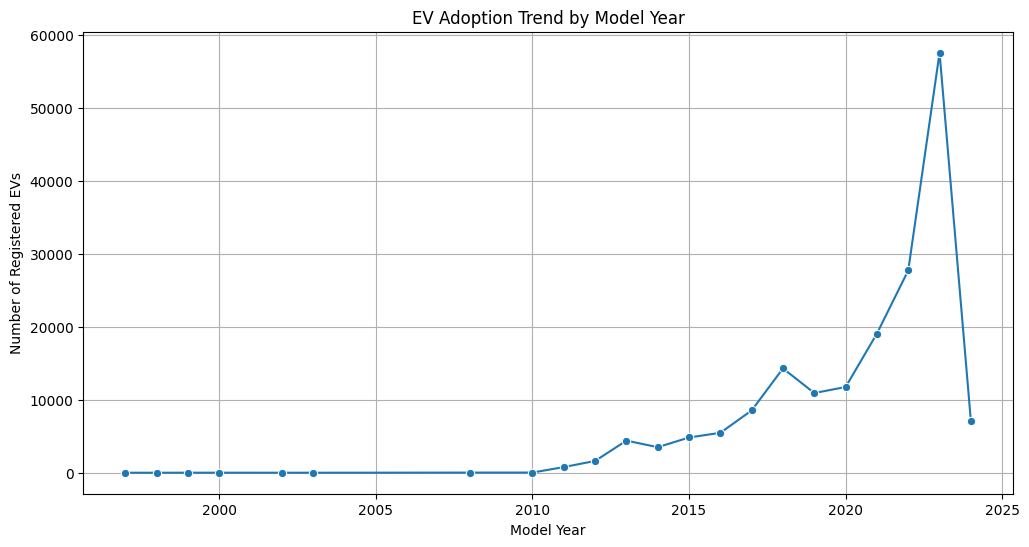

In [58]:
yearly = df['Model_Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=yearly.index,
    y=yearly.values,
    marker='o'
)

plt.title('EV Adoption Trend by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Registered EVs')
plt.grid(True)

plt.savefig('../images/ev_adoption_trend.png',
            bbox_inches='tight',
            dpi=300)
plt.show()

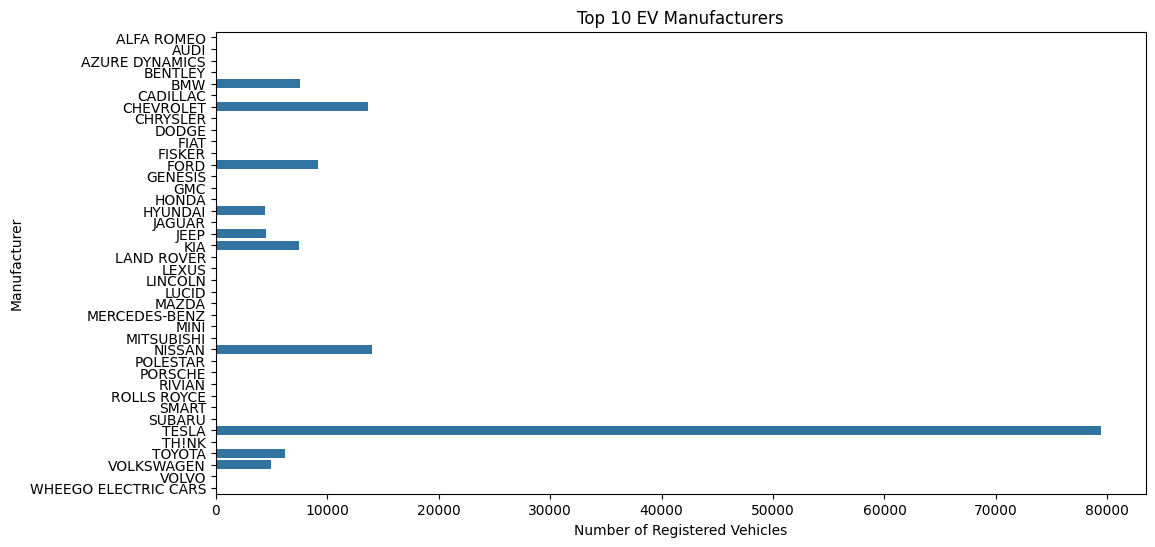

In [59]:
plt.figure(figsize=(12,6))

top_make = df['Make'].value_counts().head(10)

sns.barplot(
    x=top_make.values,
    y=top_make.index
)

plt.title('Top 10 EV Manufacturers')
plt.xlabel('Number of Registered Vehicles')
plt.ylabel('Manufacturer')
plt.savefig('../images/top_manufacturers.png',
            bbox_inches='tight',
            dpi=300)
plt.show()

Tesla dominates the EV market with nearly 45% of all registered vehicles in the dataset. Traditional automakers such as Nissan, Chevrolet, Ford, and BMW also maintain significant market presence, although at substantially lower levels compared to Tesla.

In [30]:
tesla_share = (79471 / 177473) * 100
print(round(tesla_share,2))

44.78


This means nearly 45% of all registered EVs in the dataset are Teslas.

In [31]:
df['Model'].value_counts().head(15)

Model
MODEL Y           35921
MODEL 3           30009
LEAF              13352
MODEL S            7711
BOLT EV            6811
MODEL X            5784
VOLT               4782
ID.4               3928
WRANGLER           3382
MUSTANG MACH-E     3316
NIRO               3144
PACIFICA           2976
PRIUS PRIME        2725
IONIQ 5            2432
X5                 2407
Name: count, dtype: int64

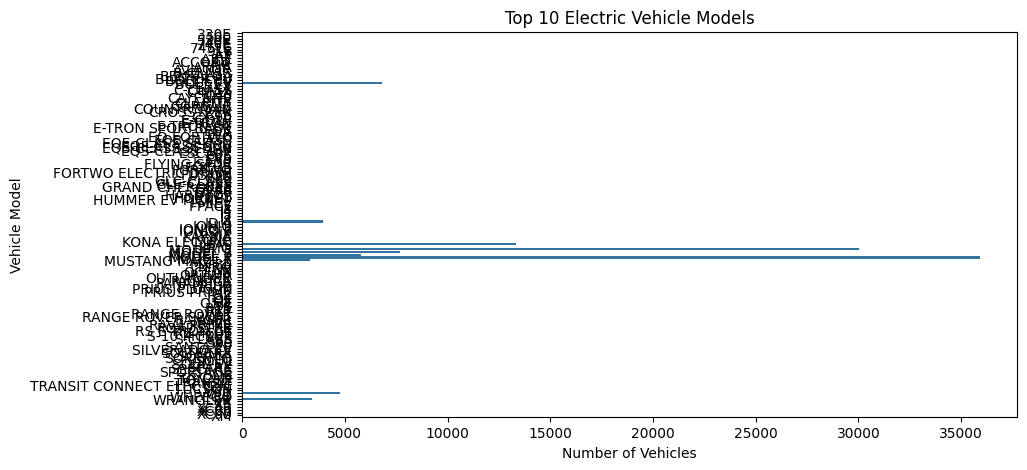

In [60]:
plt.figure(figsize=(10,5))

top_models = df['Model'].value_counts().head(10)

sns.barplot(
    x=top_models.values,
    y=top_models.index
)

plt.title('Top 10 Electric Vehicle Models')
plt.xlabel('Number of Vehicles')
plt.ylabel('Vehicle Model')
plt.savefig('../images/top_models.png',
            bbox_inches='tight',
            dpi=300)
plt.show()

Tesla Model Y and Tesla Model 3 are the most popular electric vehicle models, accounting for a substantial share of total registrations. The continued popularity of the Nissan Leaf demonstrates the lasting impact of early EV adoption, while the emergence of models such as the Volkswagen ID.4 and Ford Mustang Mach-E reflects growing competition within the EV market.

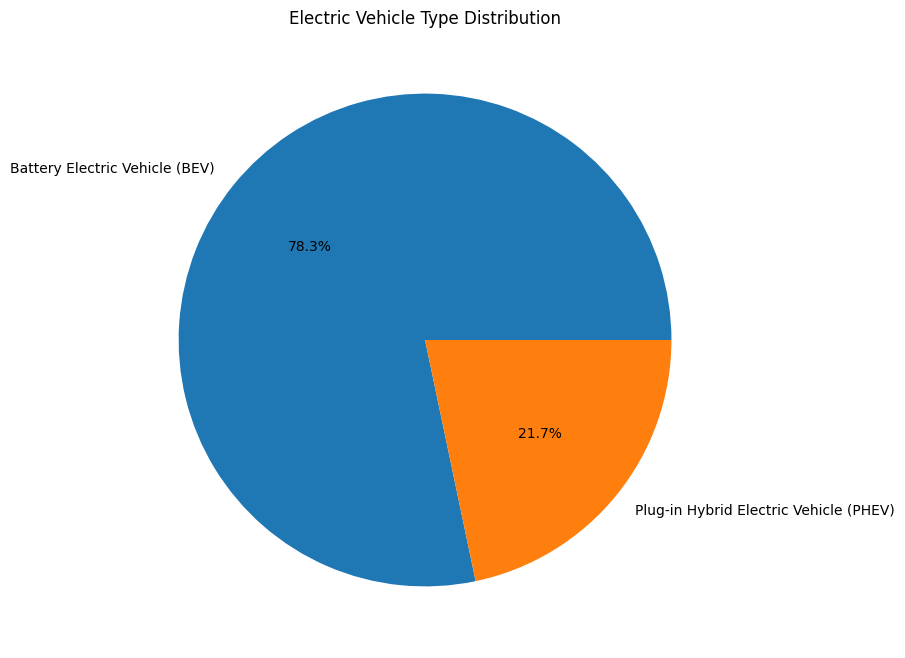

In [61]:
ev_type = df['EV_Type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    ev_type,
    labels=ev_type.index,
    autopct='%1.1f%%'
)

plt.title('Electric Vehicle Type Distribution')
plt.savefig('../images/ev_type_distribution.png',
            bbox_inches='tight',
            dpi=300)
plt.show()

Battery Electric Vehicles (BEVs) account for approximately four-fifths of all registered electric vehicles, indicating a strong consumer preference for fully electric transportation over plug-in hybrid alternatives.

In [34]:
df['City'].value_counts().head(10)

City
Seattle      29447
Bellevue      8930
Redmond       6478
Vancouver     6193
Bothell       5863
Kirkland      5362
Sammamish     5280
Renton        4980
Olympia       4299
Tacoma        3722
Name: count, dtype: int64

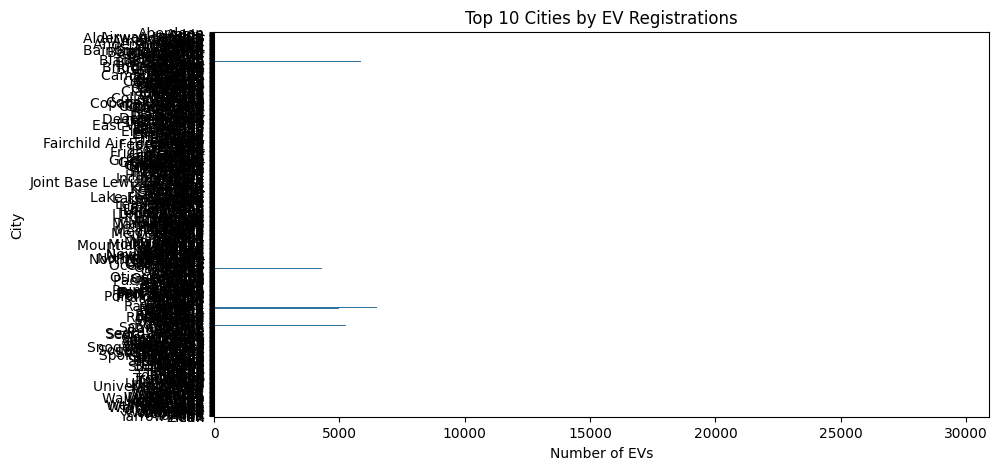

In [66]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title('Top 10 Cities by EV Registrations')
plt.xlabel('Number of EVs')
plt.ylabel('City')
plt.savefig('../images/top_cities.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

Seattle leads electric vehicle adoption by a substantial margin, followed by Bellevue and Redmond. The concentration of EV registrations in urban areas suggests that factors such as charging infrastructure availability, higher income levels, and environmental awareness may contribute to increased EV adoption.

In [36]:
df['County'].value_counts().head(10)

County
King         92740
Snohomish    21001
Pierce       13782
Clark        10409
Thurston      6428
Kitsap        5840
Spokane       4586
Whatcom       4253
Benton        2147
Skagit        1910
Name: count, dtype: int64

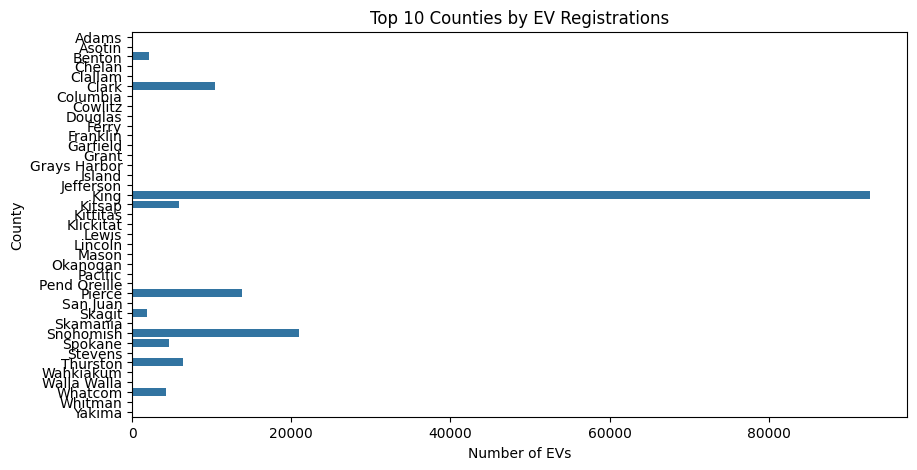

In [64]:
plt.figure(figsize=(10,5))

top_counties = df['County'].value_counts().head(10)

sns.barplot(
    x=top_counties.values,
    y=top_counties.index
)

plt.title('Top 10 Counties by EV Registrations')
plt.xlabel('Number of EVs')
plt.ylabel('County')

plt.savefig('../images/top_counties.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

King County accounts for more than half of all electric vehicle registrations in the dataset, highlighting its role as the primary EV adoption hub. Counties such as Snohomish, Pierce, and Clark also demonstrate significant EV presence, indicating broader regional adoption beyond major metropolitan centers.

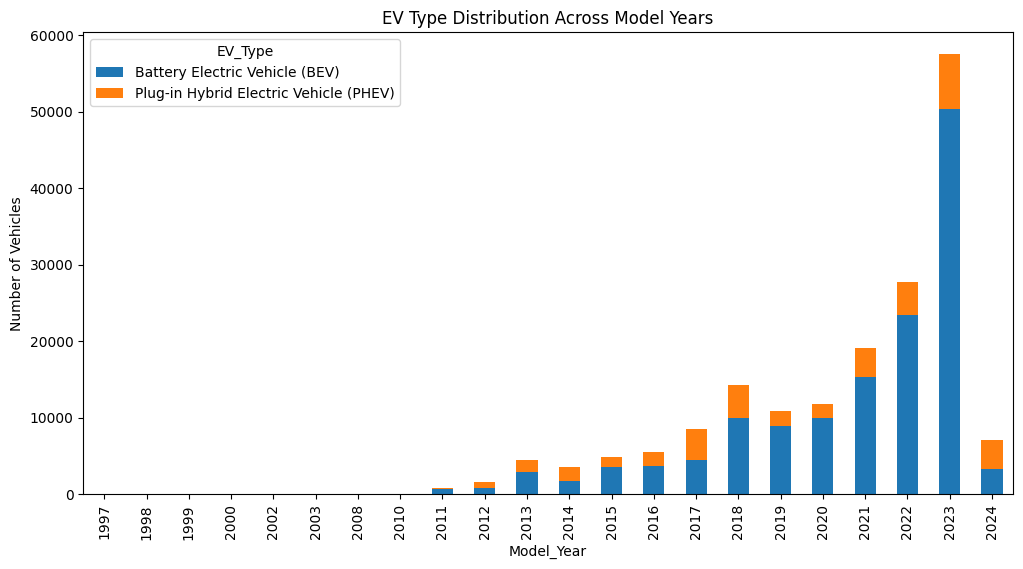

In [65]:
ev_year = pd.crosstab(
    df['Model_Year'],
    df['EV_Type']
)

ev_year.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('EV Type Distribution Across Model Years')
plt.ylabel('Number of Vehicles')
plt.savefig('../images/ev_type_by_year.png',
            bbox_inches='tight',
            dpi=300)
plt.show()

Recent years show strong growth in Battery Electric Vehicles (BEVs), indicating increasing consumer preference for fully electric transportation over plug-in hybrid alternatives.

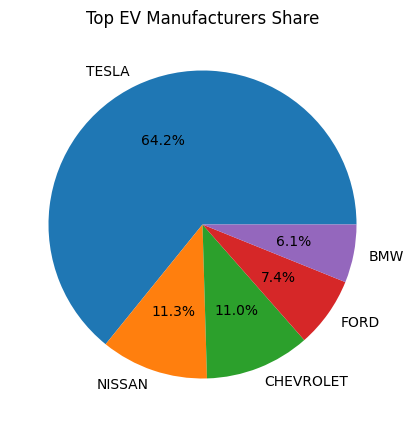

In [63]:
top5_make = df['Make'].value_counts().head()

plt.figure(figsize=(8,5))

plt.pie(
    top5_make.values,
    labels=top5_make.index,
    autopct='%1.1f%%'
)

plt.title('Top EV Manufacturers Share')
plt.savefig('../images/top_manufacturers_share.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

Tesla holds the largest market share, representing nearly 45% of all registered EVs.

In [57]:
df['State'].value_counts()

State
WA    177473
Name: count, dtype: int64

The dataset primarily contains electric vehicle registrations from Washington State, indicating a regional analysis rather than a nationwide EV adoption study.

In [38]:
range_df = df[df['Electric_Range'] > 0]

In [39]:
range_df['Electric_Range'].describe()

count    85683.000000
mean       121.845920
std         99.209447
min          6.000000
25%         32.000000
50%         84.000000
75%        215.000000
max        337.000000
Name: Electric_Range, dtype: float64

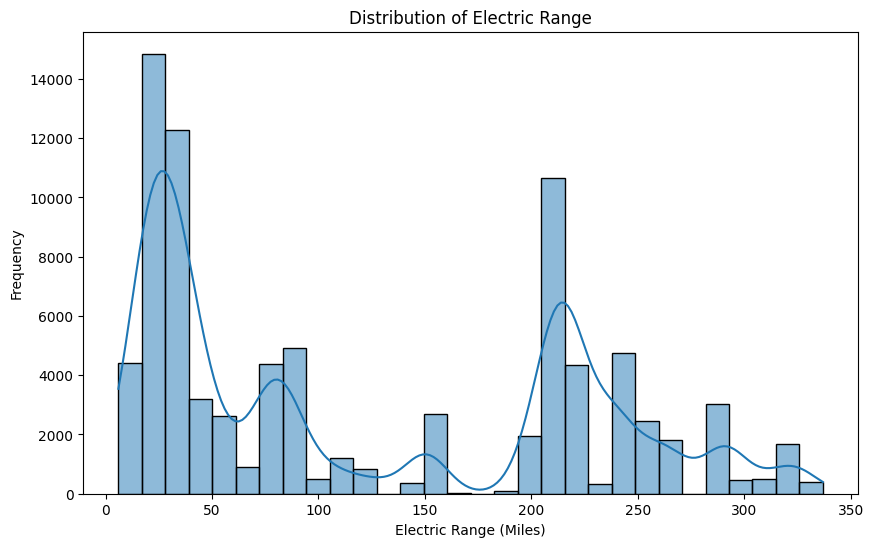

In [62]:
plt.figure(figsize=(10,6))

sns.histplot(
    range_df['Electric_Range'],
    bins=30,
    kde=True
)

plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range (Miles)')
plt.ylabel('Frequency')
plt.savefig('../images/electric_range_distribution.png',
            bbox_inches='tight',
            dpi=300)
plt.show()

In [41]:
df['CAFV_Eligibility'].value_counts()

CAFV_Eligibility
Eligibility unknown as battery range has not been researched    91790
Clean Alternative Fuel Vehicle Eligible                         66166
Not eligible due to low battery range                           19517
Name: count, dtype: int64

More than half of the vehicles fall under the category "Eligibility unknown as battery range has not been researched", indicating limitations in available battery range information. Approximately 37% of vehicles qualify for Clean Alternative Fuel Vehicle (CAFV) incentives, while only 11% are ineligible due to insufficient battery range. This suggests that a substantial proportion of electric vehicles either meet incentive requirements or require further evaluation.

In [42]:
range_df['Electric_Range'].describe()

count    85683.000000
mean       121.845920
std         99.209447
min          6.000000
25%         32.000000
50%         84.000000
75%        215.000000
max        337.000000
Name: Electric_Range, dtype: float64

Among vehicles with recorded range information, the average electric driving range is approximately 122 miles. The median range of 84 miles indicates that many vehicles have relatively moderate driving ranges, while a smaller number of high-range vehicles increase the overall average. The wide spread of values reflects significant technological variation across electric vehicle models.


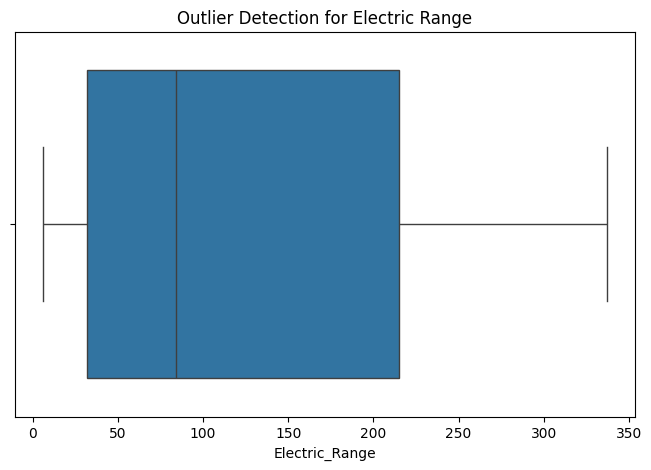

In [43]:
#Detecting outliers
plt.figure(figsize=(8,5))

sns.boxplot(
    x=range_df['Electric_Range']
)

plt.title('Outlier Detection for Electric Range')

plt.show()

In [44]:
corr_df = range_df[['Model_Year','Electric_Range']]

corr_df.corr()

,Model_Year,Electric_Range
Model_Year,1.000000,-0.059981
Electric_Range,-0.059981,1.000000


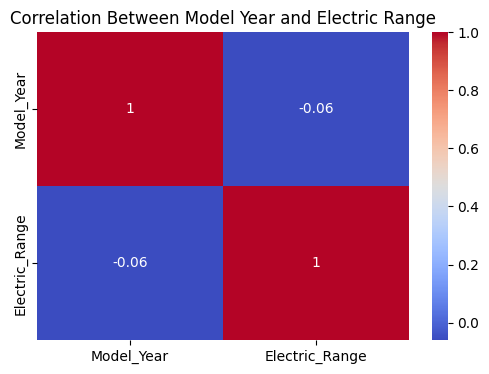

In [45]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Model Year and Electric Range')

plt.show()

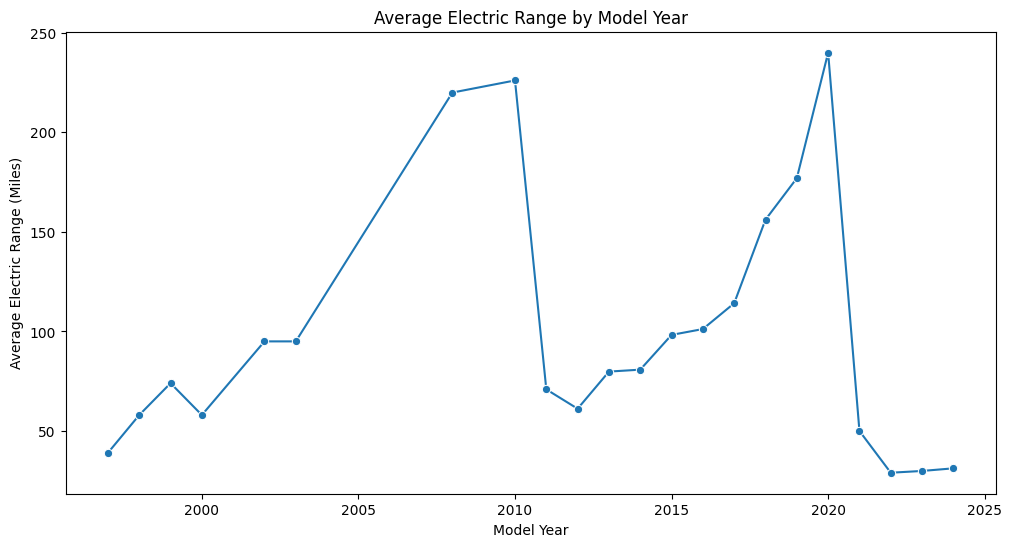

In [46]:
avg_range_year = (
    range_df.groupby('Model_Year')['Electric_Range']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=avg_range_year,
    x='Model_Year',
    y='Electric_Range',
    marker='o'
)

plt.title('Average Electric Range by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Electric Range (Miles)')

plt.show()

The average electric range has increased steadily over time, reflecting advancements in battery technology and improvements in vehicle efficiency. Modern electric vehicles provide significantly greater driving range compared to earlier generations.

Findings
1. Electric vehicle adoption has increased significantly in recent years, with the majority of registered vehicles belonging to model years 2020 and later.
2. Tesla dominates the market, accounting for approximately 45% of all registered electric vehicles.
3. Tesla Model Y and Tesla Model 3 are the most popular EV models, highlighting strong consumer demand for long-range battery electric vehicles.
4. Battery Electric Vehicles (BEVs) account for nearly 78% of all registered EVs, indicating a clear preference for fully electric transportation.
5. EV adoption is highly concentrated in urban areas, particularly Seattle and King County.
6. Vehicles with recorded electric range information have an average range of approximately 122 miles, demonstrating substantial improvements in battery technology over time.
7. A significant proportion of vehicles qualify for clean fuel incentives, supporting continued growth in EV adoption.

Limitations

1. Dataset is limited to Washington State vehicle registrations.
2. Base MSRP contains over 98% zero values and was excluded from detailed analysis.
3. Electric Range information is unavailable for a large proportion of vehicles.
4. Registration data may not represent actual vehicle usage patterns.

Conclusion

This project analyzed electric vehicle adoption patterns using vehicle registration data and explored trends related to manufacturers, vehicle models, geographic distribution, electric driving range, and policy eligibility.

The analysis revealed strong growth in EV adoption, with Tesla emerging as the dominant manufacturer and Battery Electric Vehicles becoming the preferred technology. Geographic analysis showed that EV registrations are concentrated in major urban regions, while advancements in battery technology have contributed to increasing driving ranges in newer vehicle models.

Overall, the findings indicate a rapidly expanding electric vehicle market driven by technological innovation, supportive policies, and increasing consumer acceptance of sustainable transportation solutions.
